In [1]:
import importlib, subprocess, sys

REQUIRED = {'ultralytics': 'ultralytics>=8.3.0', 'cv2': 'opencv-python', 'tqdm': 'tqdm'}
missing = []
for mod, pkg in REQUIRED.items():
    try:
        importlib.import_module(mod)
    except ImportError:
        missing.append(pkg)
if missing:
    print('Installing missing packages:', missing)
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/home/kirilllesniak/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
import os, json, glob, shutil, time, random, math
from pathlib import Path
from collections import Counter

import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

random.seed(0); np.random.seed(0); torch.manual_seed(0)

device = 0 if torch.cuda.is_available() else 'cpu'
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), 'GB')
print('Device:', device)

PyTorch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 2080 SUPER
VRAM: 7.6 GB
Device: 0


In [3]:
LAB = Path(os.getcwd()).resolve()
if LAB.name != 'lab-6':
    candidate = LAB / 'lab-6'
    if candidate.exists():
        LAB = candidate.resolve()
DATA = LAB / 'data'
TRAIN_RAW = DATA / 'train'
VAL_RAW = DATA / 'val'
YOLO_DIR = DATA / 'yolo'
REAL_DIR = DATA / 'real_photos'
RUNS_DIR = LAB / 'runs'
RESULTS_PATH = LAB / 'results.json'

for p in [YOLO_DIR/'images'/'train', YOLO_DIR/'images'/'val', YOLO_DIR/'labels'/'train', YOLO_DIR/'labels'/'val']:
    p.mkdir(parents=True, exist_ok=True)
REAL_DIR.mkdir(parents=True, exist_ok=True)

# COCO id -> local class
CLASS_REMAP = {1: 0, 2: 1, 3: 2, 4: 3, 6: 4, 8: 5, 10: 6, 13: 7}
CLASS_NAMES = ['person', 'bicycle', 'car', 'motorcycle', 'bus', 'truck', 'traffic_light', 'stop_sign']
NUM_CLASSES = len(CLASS_NAMES)

print('LAB:', LAB)
print('DATA exists:', DATA.exists(), '| train:', TRAIN_RAW.exists(), '| val:', VAL_RAW.exists())

LAB: /mnt/data/itmo-cv/lab-6
DATA exists: True | train: True | val: True


In [4]:
def scan_split(folder):
    counts = Counter(); n_imgs = 0; n_inst = 0
    for f in glob.glob(str(folder / '*_coco.json')):
        with open(f) as fd:
            d = json.load(fd)
        n_imgs += 1
        counts.update(d['class_ids'])
        n_inst += len(d['class_ids'])
    return n_imgs, n_inst, counts

tr_imgs, tr_inst, tr_hist = scan_split(TRAIN_RAW)
va_imgs, va_inst, va_hist = scan_split(VAL_RAW)
print(f'TRAIN: {tr_imgs} images, {tr_inst} instances')
print(f'VAL:   {va_imgs} images, {va_inst} instances')
print()
print(f'{"id":>3} {"name":<14} {"train":>7} {"val":>5}')
for coco_id, local in CLASS_REMAP.items():
    print(f'{local:>3} {CLASS_NAMES[local]:<14} {tr_hist.get(coco_id, 0):>7} {va_hist.get(coco_id, 0):>5}')

TRAIN: 2054 images, 13489 instances
VAL:   127 images, 739 instances

 id name             train   val
  0 person            1378    84
  1 bicycle             19     0
  2 car               9933   531
  3 motorcycle          14     0
  4 bus                111     9
  5 truck             1435    86
  6 traffic_light      597    28
  7 stop_sign            2     1


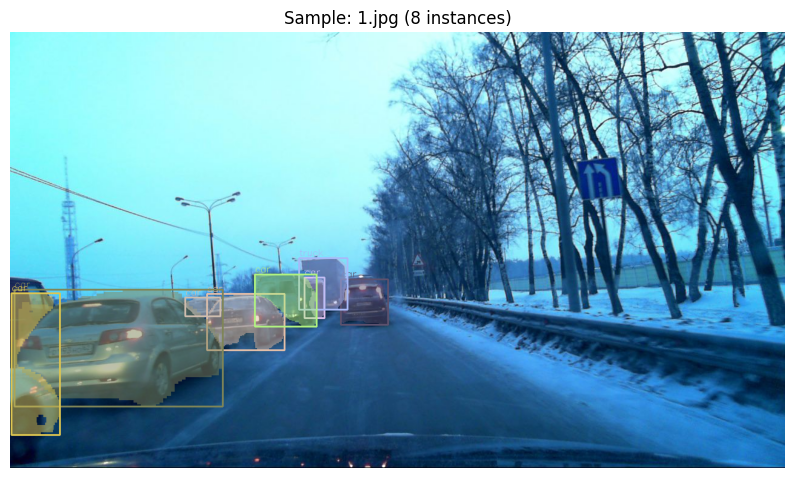

In [5]:
def reconstruct_masks(img_shape, masks_56, rois):
    H, W = img_shape[:2]
    full = []
    masks_56 = np.asarray(masks_56, dtype=np.uint8)
    for i in range(masks_56.shape[2]):
        y1, x1, y2, x2 = [int(v) for v in rois[i]]
        y1, x1 = max(0, y1), max(0, x1)
        y2, x2 = min(H, y2), min(W, x2)
        canvas = np.zeros((H, W), dtype=np.uint8)
        if y2 > y1 + 1 and x2 > x1 + 1:
            m = cv2.resize(masks_56[:, :, i], (x2 - x1, y2 - y1), interpolation=cv2.INTER_NEAREST)
            canvas[y1:y2, x1:x2] = m
        full.append(canvas)
    return full

# preview one sample
sample_img = sorted(glob.glob(str(TRAIN_RAW / '*.jpg')))[0]
sample_json = sample_img + '_coco.json'
img = cv2.imread(sample_img)[:, :, ::-1]
with open(sample_json) as f:
    sample_ann = json.load(f)
fmasks = reconstruct_masks(img.shape, sample_ann['masks'], sample_ann['rois'])

vis = img.copy()
rng = np.random.default_rng(0)
for k, (m, c) in enumerate(zip(fmasks, sample_ann['class_ids'])):
    color = rng.integers(80, 255, size=3, dtype=np.int32)
    overlay_img = vis.copy()
    overlay_img[m.astype(bool)] = color
    vis = cv2.addWeighted(vis, 0.5, overlay_img, 0.5, 0)
    y1, x1, y2, x2 = [int(v) for v in sample_ann['rois'][k]]
    cv2.rectangle(vis, (x1, y1), (x2, y2), tuple(int(v) for v in color), 2)
    name = CLASS_NAMES[CLASS_REMAP[c]] if c in CLASS_REMAP else str(c)
    cv2.putText(vis, name, (x1, max(15, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, tuple(int(v) for v in color), 1)

plt.figure(figsize=(10, 6))
plt.imshow(vis)
plt.axis('off')
plt.title(f'Sample: {Path(sample_img).name} ({len(sample_ann["class_ids"])} instances)')
plt.show()

In [6]:
def link_or_copy(src, dst):
    src = str(src); dst = str(dst)
    if os.path.exists(dst):
        return
    try:
        os.symlink(src, dst)
        return
    except (OSError, NotImplementedError):
        pass
    try:
        os.link(src, dst)
        return
    except OSError:
        pass
    shutil.copy2(src, dst)

def coco_json_to_yolo_txt(json_path, img_path, out_label_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return False, 0
    H, W = img.shape[:2]
    with open(json_path) as f:
        d = json.load(f)
    masks = np.asarray(d['masks'], dtype=np.uint8) if d.get('masks') else None
    rois = d.get('rois', [])
    cids = d.get('class_ids', [])
    lines = []
    if masks is not None and masks.size > 0:
        for i, (cid, roi) in enumerate(zip(cids, rois)):
            if cid not in CLASS_REMAP:
                continue
            y1, x1, y2, x2 = [int(v) for v in roi]
            y1, x1 = max(0, y1), max(0, x1)
            y2, x2 = min(H, y2), min(W, x2)
            if y2 <= y1 + 1 or x2 <= x1 + 1:
                continue
            m56 = masks[:, :, i]
            m_full = cv2.resize(m56, (x2 - x1, y2 - y1), interpolation=cv2.INTER_NEAREST)
            canvas = np.zeros((H, W), dtype=np.uint8)
            canvas[y1:y2, x1:x2] = m_full
            contours, _ = cv2.findContours(canvas, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            if not contours:
                continue
            cnt = max(contours, key=cv2.contourArea)
            if cv2.contourArea(cnt) < 8:
                continue
            eps = max(0.5, 0.0025 * cv2.arcLength(cnt, True))
            poly = cv2.approxPolyDP(cnt, eps, True).reshape(-1, 2)
            if len(poly) < 3:
                continue
            coords = []
            for x, y in poly:
                coords.append(min(max(float(x) / W, 0.0), 1.0))
                coords.append(min(max(float(y) / H, 0.0), 1.0))
            lines.append(f'{CLASS_REMAP[cid]} ' + ' '.join(f'{c:.6f}' for c in coords))
    out_label_path = Path(out_label_path)
    out_label_path.parent.mkdir(parents=True, exist_ok=True)
    with open(out_label_path, 'w') as f:
        f.write('\n'.join(lines))
    return True, len(lines)

def convert_split(src_dir, img_dst_dir, lbl_dst_dir):
    img_paths = sorted(glob.glob(str(src_dir / '*.jpg')))
    n_ok, n_skipped, total_inst = 0, 0, 0
    for img_path in tqdm(img_paths, desc=f'Converting {src_dir.name}'):
        json_path = img_path + '_coco.json'
        if not os.path.exists(json_path):
            n_skipped += 1; continue
        name = Path(img_path).name
        out_lbl = Path(lbl_dst_dir) / (Path(name).stem + '.txt')
        ok, n_inst = coco_json_to_yolo_txt(json_path, img_path, out_lbl)
        if not ok:
            n_skipped += 1; continue
        link_or_copy(img_path, Path(img_dst_dir) / name)
        n_ok += 1; total_inst += n_inst
    return n_ok, n_skipped, total_inst

t0 = time.time()
tr_ok, tr_skip, tr_inst_kept = convert_split(TRAIN_RAW, YOLO_DIR/'images'/'train', YOLO_DIR/'labels'/'train')
va_ok, va_skip, va_inst_kept = convert_split(VAL_RAW, YOLO_DIR/'images'/'val', YOLO_DIR/'labels'/'val')
print(f'\nTRAIN: ok={tr_ok}, skipped={tr_skip}, instances kept={tr_inst_kept}')
print(f'VAL:   ok={va_ok}, skipped={va_skip}, instances kept={va_inst_kept}')
print(f'Conversion took {time.time()-t0:.1f}s')

Converting train:   0%|          | 0/2054 [00:00<?, ?it/s]

Converting train:   1%|          | 14/2054 [00:00<00:14, 137.33it/s]

Converting train:   2%|▏         | 36/2054 [00:00<00:11, 183.17it/s]

Converting train:   3%|▎         | 55/2054 [00:00<00:14, 134.47it/s]

Converting train:   3%|▎         | 70/2054 [00:00<00:18, 107.25it/s]

...

Converting val:  82%|████████▏ | 104/127 [00:01<00:00, 79.17it/s]

Converting val:  94%|█████████▎| 119/127 [00:01<00:00, 67.99it/s]

Converting val: 100%|██████████| 127/127 [00:01<00:00, 56.01it/s]

Converting val: 100%|██████████| 127/127 [00:01<00:00, 69.97it/s]


TRAIN: ok=2054, skipped=0, instances kept=13489
VAL:   ok=127, skipped=0, instances kept=739
Conversion took 20.7s


In [7]:
data_yaml = YOLO_DIR / 'data.yaml'
with open(data_yaml, 'w') as f:
    f.write(f'path: {YOLO_DIR}\n')
    f.write('train: images/train\n')
    f.write('val: images/val\n')
    f.write(f'nc: {NUM_CLASSES}\n')
    f.write('names: ' + json.dumps(CLASS_NAMES) + '\n')
print(open(data_yaml).read())

path: /mnt/data/itmo-cv/lab-6/data/yolo
train: images/train
val: images/val
nc: 8
names: ["person", "bicycle", "car", "motorcycle", "bus", "truck", "traffic_light", "stop_sign"]



In [8]:
from ultralytics import YOLO

MODEL_NAME = 'yolo11s-seg.pt'
EPOCHS = 50
IMG_SIZE = 640
BATCH = 16
PATIENCE = 15
RUN_NAME = 'signs_yolo11s'

model = YOLO(MODEL_NAME)
print('Loaded:', MODEL_NAME)

t_start = time.time()
train_results = model.train(
    data=str(data_yaml),
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH,
    patience=PATIENCE,
    cache='ram',
    amp=True,
    device=device,
    project=str(RUNS_DIR),
    name=RUN_NAME,
    exist_ok=True,
    plots=True,
    verbose=True,
    seed=0,
)
training_seconds = time.time() - t_start
print(f'\nTraining wall time: {training_seconds/60:.1f} minutes')
best_pt = Path(train_results.save_dir) / 'weights' / 'best.pt'
print('Best weights:', best_pt)

Loaded: yolo11s-seg.pt


Ultralytics 8.4.43 🚀 Python-3.12.3 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2080 SUPER, 7784MiB)


engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=ram, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/mnt/data/itmo-cv/lab-6/data/yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=signs_yolo11s, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=15, perspective=0.0, plots=True, pose=12.0, pretrained=True, profil

Overriding model.yaml nc=80 with nc=8



                   from  n    params  module                                       arguments                     


...

         traffic_light         20         28      0.766      0.464      0.633      0.391       0.77      0.464      0.599       0.17


             stop_sign          1          1          0          0          0          0          0          0          0          0


Speed: 0.1ms preprocess, 2.3ms inference, 0.0ms loss, 1.8ms postprocess per image


Results saved to /mnt/data/itmo-cv/lab-6/runs/signs_yolo11s



Training wall time: 26.5 minutes
Best weights: /mnt/data/itmo-cv/lab-6/runs/signs_yolo11s/weights/best.pt


In [9]:
best_model = YOLO(str(best_pt))
val_metrics = best_model.val(data=str(data_yaml), split='val', imgsz=IMG_SIZE, batch=BATCH, device=device, plots=False, verbose=False)
print('Box mAP50  :', round(float(val_metrics.box.map50), 4))
print('Box mAP50-95:', round(float(val_metrics.box.map), 4))
print('Mask mAP50 :', round(float(val_metrics.seg.map50), 4))
print('Mask mAP50-95:', round(float(val_metrics.seg.map), 4))

Ultralytics 8.4.43 🚀 Python-3.12.3 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2080 SUPER, 7784MiB)


YOLO11s-seg summary (fused): 114 layers, 10,069,912 parameters, 0 gradients, 32.8 GFLOPs


val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 1953.3±2763.1 MB/s, size: 1529.0 KB)


val: Scanning /mnt/data/itmo-cv/lab-6/data/yolo/labels/val.cache... 127 images, 12 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 127/127 88.8Mit/s 0.0s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 12% ━─────────── 1/8 1.4it/s 0.2s<5.1s

...

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 88% ━━━━━━━━━━── 7/8 8.3it/s 0.9s<0.1s

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 7.0it/s 1.1s

                   all        127        739      0.667      0.613      0.672      0.504      0.651      0.591      0.637       0.37


Speed: 0.5ms preprocess, 4.1ms inference, 0.0ms loss, 0.8ms postprocess per image


Box mAP50  : 0.6725
Box mAP50-95: 0.5041
Mask mAP50 : 0.6371
Mask mAP50-95: 0.3701


In [10]:
def load_yolo_seg_gt(label_path, H, W):
    masks, classes = [], []
    if not os.path.exists(label_path):
        return masks, classes
    with open(label_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 7:
                continue
            cls = int(parts[0])
            coords = np.asarray([float(x) for x in parts[1:]]).reshape(-1, 2)
            coords[:, 0] *= W
            coords[:, 1] *= H
            poly = coords.astype(np.int32)
            m = np.zeros((H, W), dtype=np.uint8)
            cv2.fillPoly(m, [poly], 1)
            masks.append(m.astype(bool))
            classes.append(cls)
    return masks, classes

def predict_masks(model, img_path, imgsz=640, conf=0.25):
    res = model.predict(str(img_path), imgsz=imgsz, conf=conf, verbose=False, device=device)[0]
    H, W = res.orig_shape
    masks, classes, scores = [], [], []
    if res.masks is not None and len(res.masks) > 0:
        m_arr = res.masks.data.cpu().numpy()
        cls_arr = res.boxes.cls.cpu().numpy().astype(int)
        scr_arr = res.boxes.conf.cpu().numpy()
        for k in range(m_arr.shape[0]):
            m = m_arr[k]
            if m.shape != (H, W):
                m = cv2.resize(m.astype(np.uint8), (W, H), interpolation=cv2.INTER_NEAREST)
            masks.append(m.astype(bool))
            classes.append(int(cls_arr[k]))
            scores.append(float(scr_arr[k]))
    return masks, classes, scores, (H, W)

def iou_pair(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter) / float(union) if union > 0 else 0.0

def l2_pair(a, b):
    diff = a.astype(np.float32) - b.astype(np.float32)
    return float(np.sqrt((diff * diff).sum()))

def evaluate(model, img_dir, lbl_dir, num_classes, match_iou=0.5, conf=0.25, imgsz=640, max_imgs=None, require_gt=False):
    img_files = sorted(
        glob.glob(str(Path(img_dir) / '*.jpg')) +
        glob.glob(str(Path(img_dir) / '*.jpeg')) +
        glob.glob(str(Path(img_dir) / '*.png')) +
        glob.glob(str(Path(img_dir) / '*.JPG')) +
        glob.glob(str(Path(img_dir) / '*.PNG'))
    )
    if max_imgs:
        img_files = img_files[:max_imgs]
    if require_gt:
        img_files = [ip for ip in img_files
                     if (Path(lbl_dir) / (Path(ip).stem + '.txt')).exists()
                     and (Path(lbl_dir) / (Path(ip).stem + '.txt')).stat().st_size > 0]
    tp = fp = fn = 0
    iou_per_match, l2_per_match = [], []
    image_mean_iou, image_with_gt = [], 0
    images_evaluated = 0
    for ip in tqdm(img_files, desc=f'Eval {Path(img_dir).name}'):
        H, W = cv2.imread(ip).shape[:2]
        lbl = Path(lbl_dir) / (Path(ip).stem + '.txt')
        gt_masks, gt_cls = load_yolo_seg_gt(lbl, H, W)
        pr_masks, pr_cls, pr_scr, _ = predict_masks(model, ip, imgsz=imgsz, conf=conf)
        images_evaluated += 1
        if len(gt_masks) > 0:
            image_with_gt += 1
        used_pr = set()
        used_gt = set()
        per_image_ious = []
        for c in range(num_classes):
            gt_idx = [i for i, x in enumerate(gt_cls) if x == c]
            pr_idx = [i for i, x in enumerate(pr_cls) if x == c]
            if not gt_idx or not pr_idx:
                continue
            mat = np.zeros((len(pr_idx), len(gt_idx)))
            for pi, p in enumerate(pr_idx):
                for gi, g in enumerate(gt_idx):
                    mat[pi, gi] = iou_pair(pr_masks[p], gt_masks[g])
            while True:
                pi, gi = np.unravel_index(mat.argmax(), mat.shape)
                if mat[pi, gi] <= 0:
                    break
                p, g = pr_idx[pi], gt_idx[gi]
                iou_val = float(mat[pi, gi])
                if iou_val >= match_iou:
                    tp += 1
                    used_pr.add(p); used_gt.add(g)
                    iou_per_match.append(iou_val)
                    l2_per_match.append(l2_pair(pr_masks[p], gt_masks[g]))
                    per_image_ious.append(iou_val)
                mat[pi, :] = -1; mat[:, gi] = -1
        fp += len([i for i in range(len(pr_cls)) if i not in used_pr])
        fn += len([i for i in range(len(gt_cls)) if i not in used_gt])
        if len(gt_masks) > 0:
            image_mean_iou.append(float(np.mean(per_image_ious)) if per_image_ious else 0.0)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    return {
        'images': images_evaluated,
        'images_with_gt': image_with_gt,
        'tp': tp, 'fp': fp, 'fn': fn,
        'precision': round(precision, 4),
        'recall': round(recall, 4),
        'mean_iou_matched': round(float(np.mean(iou_per_match)), 4) if iou_per_match else 0.0,
        'mean_l2_matched': round(float(np.mean(l2_per_match)), 2) if l2_per_match else 0.0,
        'frac_iou_ge_0.50': round(float(np.mean([x >= 0.50 for x in image_mean_iou])), 4) if image_mean_iou else 0.0,
        'frac_iou_ge_0.75': round(float(np.mean([x >= 0.75 for x in image_mean_iou])), 4) if image_mean_iou else 0.0,
        'frac_iou_ge_0.90': round(float(np.mean([x >= 0.90 for x in image_mean_iou])), 4) if image_mean_iou else 0.0,
    }

val_custom = evaluate(best_model, YOLO_DIR/'images'/'val', YOLO_DIR/'labels'/'val', NUM_CLASSES)
for k, v in val_custom.items():
    print(f'{k:>20}: {v}')

Eval val:   0%|          | 0/127 [00:00<?, ?it/s]

Eval val:   2%|▏         | 2/127 [00:00<00:06, 19.86it/s]

Eval val:   4%|▍         | 5/127 [00:00<00:04, 25.43it/s]

Eval val:   6%|▋         | 8/127 [00:00<00:08, 14.49it/s]

Eval val:   8%|▊         | 10/127 [00:00<00:08, 13.36it/s]

...

Eval val:  94%|█████████▍| 120/127 [00:09<00:01,  5.56it/s]

Eval val:  96%|█████████▌| 122/127 [00:09<00:00,  6.09it/s]

Eval val:  99%|█████████▉| 126/127 [00:09<00:00,  9.11it/s]

Eval val: 100%|██████████| 127/127 [00:09<00:00, 13.00it/s]

              images: 127
      images_with_gt: 115
                  tp: 514
                  fp: 290
                  fn: 225
           precision: 0.6393
              recall: 0.6955
    mean_iou_matched: 0.7305
     mean_l2_matched: 36.06
    frac_iou_ge_0.50: 0.9043
    frac_iou_ge_0.75: 0.3652
    frac_iou_ge_0.90: 0.0087


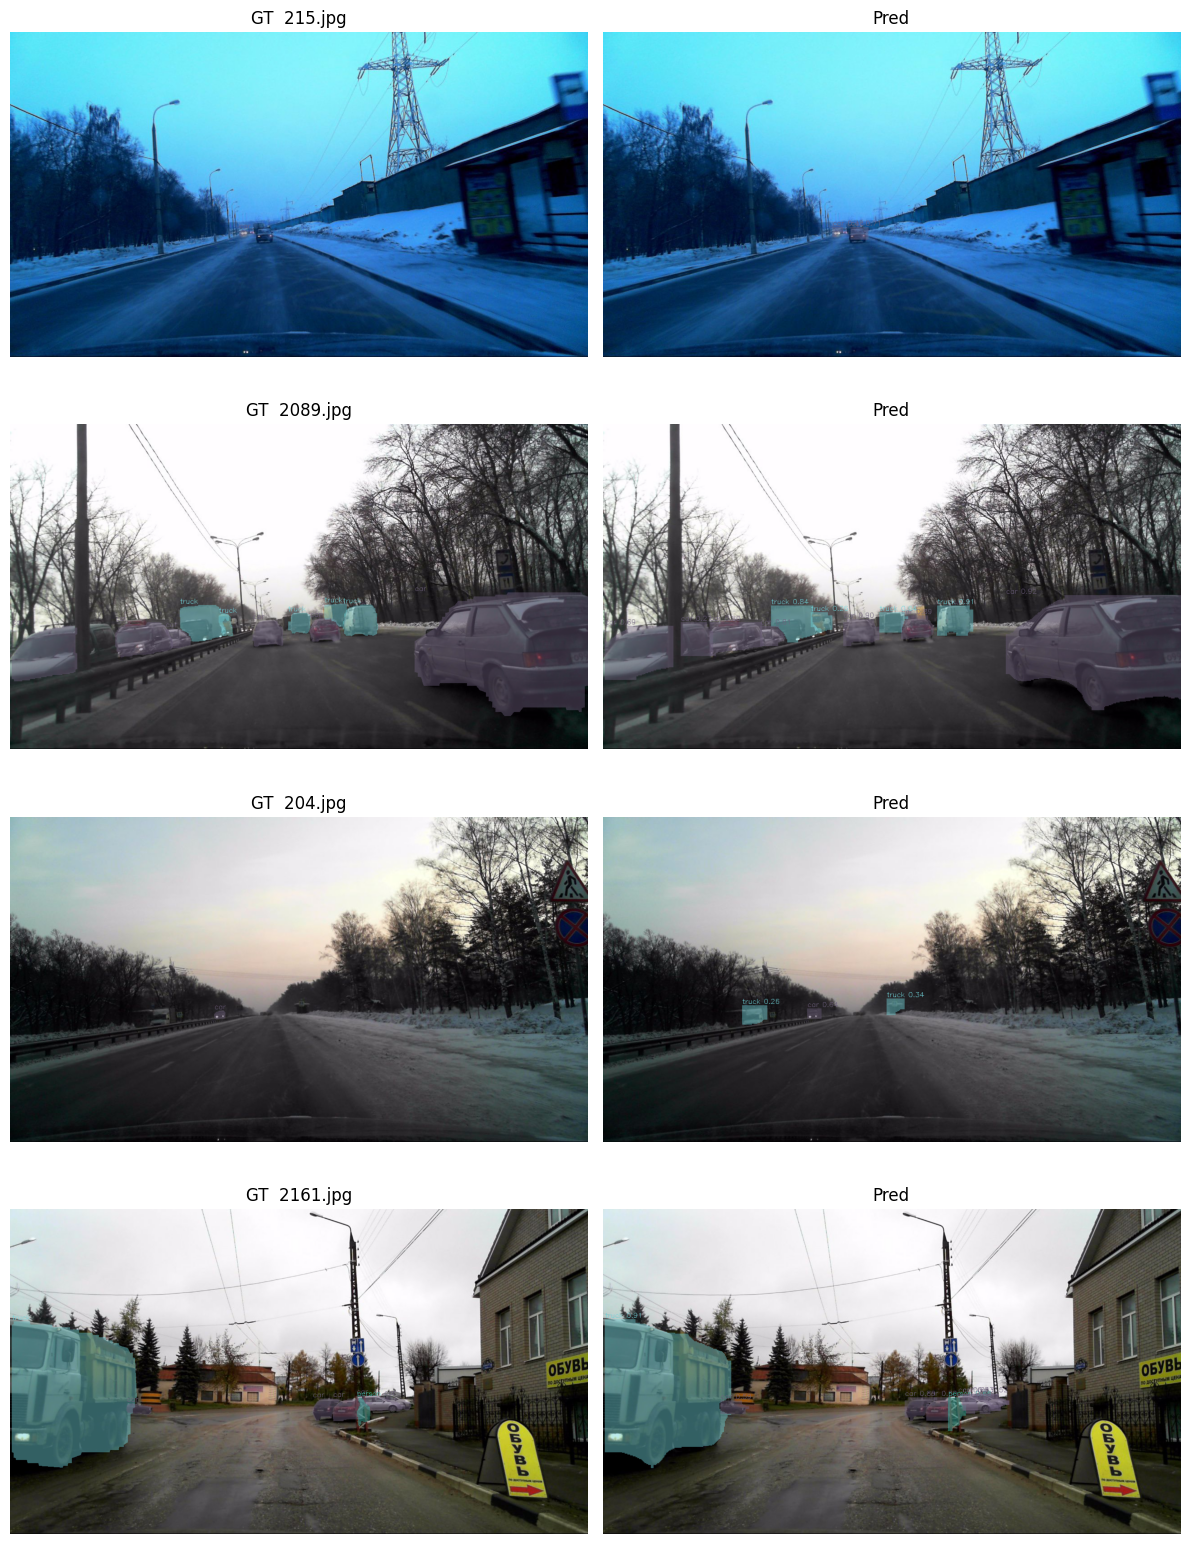

In [11]:
def overlay(img_rgb, masks, classes, scores=None, alpha=0.45):
    rng = np.random.default_rng(123)
    palette = rng.integers(60, 255, size=(NUM_CLASSES, 3), dtype=np.int32)
    out = img_rgb.copy()
    for k, (m, c) in enumerate(zip(masks, classes)):
        color = palette[c % NUM_CLASSES]
        layer = out.copy()
        layer[m] = color
        out = cv2.addWeighted(out, 1 - alpha, layer, alpha, 0)
        ys, xs = np.where(m)
        if len(xs):
            x0, y0 = int(xs.min()), int(ys.min())
            label = CLASS_NAMES[c] if 0 <= c < NUM_CLASSES else f'cls{c}'
            if scores is not None and k < len(scores):
                label += f' {scores[k]:.2f}'
            cv2.putText(out, label, (x0, max(15, y0 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, tuple(int(v) for v in color), 1)
    return out

val_imgs = sorted(glob.glob(str(YOLO_DIR/'images'/'val'/'*.jpg')))
if val_imgs:
    rng = random.Random(42)
    sample = rng.sample(val_imgs, min(4, len(val_imgs)))
    fig, axes = plt.subplots(len(sample), 2, figsize=(12, 4*len(sample)))
    if len(sample) == 1:
        axes = axes.reshape(1, 2)
    for r, ip in enumerate(sample):
        img_rgb = cv2.imread(ip)[:, :, ::-1]
        H, W = img_rgb.shape[:2]
        gt_m, gt_c = load_yolo_seg_gt(YOLO_DIR/'labels'/'val'/f'{Path(ip).stem}.txt', H, W)
        pr_m, pr_c, pr_s, _ = predict_masks(best_model, ip)
        axes[r, 0].imshow(overlay(img_rgb, gt_m, gt_c)); axes[r, 0].set_title(f'GT  {Path(ip).name}'); axes[r, 0].axis('off')
        axes[r, 1].imshow(overlay(img_rgb, pr_m, pr_c, pr_s)); axes[r, 1].set_title('Pred'); axes[r, 1].axis('off')
    plt.tight_layout(); plt.show()

In [12]:
real_imgs = sorted(
    glob.glob(str(REAL_DIR / '*.jpg')) +
    glob.glob(str(REAL_DIR / '*.jpeg')) +
    glob.glob(str(REAL_DIR / '*.png')) +
    glob.glob(str(REAL_DIR / '*.JPG')) +
    glob.glob(str(REAL_DIR / '*.PNG'))
)
real_metrics = None
if not real_imgs:
    print(f'[skip] Нет уличных фото в {REAL_DIR}.\nПоложите туда 10 jpg/png и перезапустите этот раздел.')
else:
    print(f'Found {len(real_imgs)} real photo(s).')
    real_lbl_dir = REAL_DIR / 'labels'
    real_lbl_dir.mkdir(exist_ok=True)
    real_have_gt = 0
    for ip in real_imgs:
        stem = Path(ip).stem
        existing_txt = Path(ip).with_suffix('.txt')
        existing_json = Path(str(ip) + '_coco.json')
        out_txt = real_lbl_dir / (stem + '.txt')
        if existing_txt.exists():
            shutil.copy2(existing_txt, out_txt)
            if out_txt.stat().st_size > 0:
                real_have_gt += 1
        elif existing_json.exists():
            ok, _ = coco_json_to_yolo_txt(existing_json, ip, out_txt)
            if ok and out_txt.stat().st_size > 0:
                real_have_gt += 1
        else:
            out_txt.write_text('')

    pred_dir = REAL_DIR / 'predictions'
    pred_dir.mkdir(exist_ok=True)
    n = len(real_imgs)
    fig, axes = plt.subplots(n, 1, figsize=(10, 5 * n))
    if n == 1:
        axes = [axes]
    for i, ip in enumerate(real_imgs):
        img_rgb = cv2.imread(ip)[:, :, ::-1]
        pr_m, pr_c, pr_s, _ = predict_masks(best_model, ip)
        vis = overlay(img_rgb, pr_m, pr_c, pr_s)
        out_path = pred_dir / Path(ip).name
        cv2.imwrite(str(out_path), vis[:, :, ::-1])
        axes[i].imshow(vis); axes[i].set_title(f'{Path(ip).name} — {len(pr_m)} det'); axes[i].axis('off')
    plt.tight_layout(); plt.show()

    if real_have_gt > 0:
        print(f'Computing custom metrics on {real_have_gt} annotated real photo(s)...')
        real_metrics = evaluate(best_model, REAL_DIR, real_lbl_dir, NUM_CLASSES, require_gt=True)
        for k, v in real_metrics.items():
            print(f'  {k:>20}: {v}')
    else:
        print('Нет аннотированных фото — метрики на real photos помечены как null.\n'
              'Чтобы добавить разметку, положите рядом с image.jpg файл image.txt в YOLO seg формате\n'
              '(или image.jpg_coco.json в формате train/, тогда конвертация автоматическая).')

[skip] Нет уличных фото в /mnt/data/itmo-cv/lab-6/data/real_photos.
Положите туда 10 jpg/png и перезапустите этот раздел.


In [13]:
results = {
    'task': 'instance_segmentation',
    'dataset': 'Russian road signs (Mask R-CNN pseudo-labels, 8 COCO classes)',
    'model': 'YOLO11s-seg (pretrained COCO, fine-tuned)',
    'num_classes': NUM_CLASSES,
    'classes': CLASS_NAMES,
    'class_remap_coco_to_local': {str(k): v for k, v in CLASS_REMAP.items()},
    'train_size': tr_ok,
    'val_size': va_ok,
    'hyperparameters': {
        'imgsz': IMG_SIZE,
        'batch': BATCH,
        'epochs': EPOCHS,
        'patience': PATIENCE,
        'optimizer': 'auto',
        'amp': True,
        'cache': 'ram',
        'device': str(device),
    },
    'training_seconds': round(training_seconds, 1),
    'training_minutes': round(training_seconds / 60, 1),
    'best_weights': str(best_pt),
    'ultralytics_metrics': {
        'box_mAP50': round(float(val_metrics.box.map50), 4),
        'box_mAP50_95': round(float(val_metrics.box.map), 4),
        'mask_mAP50': round(float(val_metrics.seg.map50), 4),
        'mask_mAP50_95': round(float(val_metrics.seg.map), 4),
    },
    'custom_metrics_val': val_custom,
    'custom_metrics_real_photos': real_metrics,
}
with open(RESULTS_PATH, 'w') as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))

{
  "task": "instance_segmentation",
  "dataset": "Russian road signs (Mask R-CNN pseudo-labels, 8 COCO classes)",
  "model": "YOLO11s-seg (pretrained COCO, fine-tuned)",
  "num_classes": 8,
  "classes": [
    "person",
    "bicycle",
    "car",
    "motorcycle",
    "bus",
    "truck",
    "traffic_light",
    "stop_sign"
  ],
  "class_remap_coco_to_local": {
    "1": 0,
    "2": 1,
    "3": 2,
    "4": 3,
    "6": 4,
    "8": 5,
    "10": 6,
    "13": 7
  },
  "train_size": 2054,
  "val_size": 127,
  "hyperparameters": {
    "imgsz": 640,
    "batch": 16,
    "epochs": 50,
    "patience": 15,
    "optimizer": "auto",
    "amp": true,
    "cache": "ram",
    "device": "0"
  },
  "training_seconds": 1588.8,
  "training_minutes": 26.5,
  "best_weights": "/mnt/data/itmo-cv/lab-6/runs/signs_yolo11s/weights/best.pt",
  "ultralytics_metrics": {
    "box_mAP50": 0.6725,
    "box_mAP50_95": 0.5041,
    "mask_mAP50": 0.6371,
    "mask_mAP50_95": 0.3701
  },
  "custom_metrics_val": {
    "image